In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor


# 4. Household Electric Power Consumption Regression

## 4.1 EDA and Data Processing

## A

In [4]:
data = pd.read_csv('household_power_consumption.txt', sep=';')

C:\Users\fajer\AppData\Local\Temp\ipykernel_28000\208285862.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('household_power_consumption.txt', sep=';')


In [5]:
data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Looking at out dara we can see how it is distributed. Our target is Global_active_power, and the others are the independent variables, which we will study if they are useful or not to predict the target (in this case do the regression).

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


The first interesting thing we see is that almost all columns are object-type. This is wrong, because in our data.head() we see information which should be float and Date and Time columns should be in a more suitable format (like datetime). This is te first thing we are going to do.

## Changing Types and processing missing values

Before changing types we have to look at our missing values. In the kaggle explanation of the dataset, it says that we look to a specific date to see how missing values are presented. This rows are the measurements from 28/4/2007.

In [7]:
data[data["Date"] == "28/4/2007"]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
190476,28/4/2007,00:00:00,1.368,0.086,233.050,5.800,0.000,1.000,0.0
190477,28/4/2007,00:01:00,1.370,0.086,233.220,5.800,0.000,1.000,0.0
190478,28/4/2007,00:02:00,1.372,0.088,233.570,5.800,0.000,2.000,0.0
190479,28/4/2007,00:03:00,1.370,0.086,233.400,5.800,0.000,1.000,0.0
190480,28/4/2007,00:04:00,1.368,0.086,233.250,5.800,0.000,1.000,0.0
...,...,...,...,...,...,...,...,...,...
191911,28/4/2007,23:55:00,?,?,?,?,?,?,NaN
191912,28/4/2007,23:56:00,?,?,?,?,?,?,NaN
191913,28/4/2007,23:57:00,?,?,?,?,?,?,NaN
191914,28/4/2007,23:58:00,?,?,?,?,?,?,NaN


Now we understand why our data is in object type. Missing values are presented as '?', so our DataFrame detects the rows as object. 

In [8]:
columns_to_check = ["Date", "Time","Global_active_power",  "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

for col in columns_to_check:
    print(f"{col}: {data[col].eq('?').sum()} rows with '?'")

Date: 0 rows with '?'
Time: 0 rows with '?'
Global_active_power: 25979 rows with '?'
Global_reactive_power: 25979 rows with '?'
Voltage: 25979 rows with '?'
Global_intensity: 25979 rows with '?'
Sub_metering_1: 25979 rows with '?'
Sub_metering_2: 25979 rows with '?'
Sub_metering_3: 0 rows with '?'


In [9]:
for col in columns_to_check:
    print(f"{col}: {data[col].isna().sum()} NaN values")

Date: 0 NaN values
Time: 0 NaN values
Global_active_power: 0 NaN values
Global_reactive_power: 0 NaN values
Voltage: 0 NaN values
Global_intensity: 0 NaN values
Sub_metering_1: 0 NaN values
Sub_metering_2: 0 NaN values
Sub_metering_3: 25979 NaN values


Here we can see our missing values distribution. It is interesting to see that missing values are presened for all the row execpt for Data and time. In all columns the missing value is presented as '?' and in the last columns with None.

The first thing we are going to do is replace '?' with NaN in order to be able to treat them.

In [10]:
for col in data.columns:
    data[col] = data[col].replace("?", np.nan)

In [11]:
data[data["Date"] == "28/4/2007"]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
190476,28/4/2007,00:00:00,1.368,0.086,233.050,5.800,0.000,1.000,0.0
190477,28/4/2007,00:01:00,1.370,0.086,233.220,5.800,0.000,1.000,0.0
190478,28/4/2007,00:02:00,1.372,0.088,233.570,5.800,0.000,2.000,0.0
190479,28/4/2007,00:03:00,1.370,0.086,233.400,5.800,0.000,1.000,0.0
190480,28/4/2007,00:04:00,1.368,0.086,233.250,5.800,0.000,1.000,0.0
...,...,...,...,...,...,...,...,...,...
191911,28/4/2007,23:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191912,28/4/2007,23:56:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191913,28/4/2007,23:57:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191914,28/4/2007,23:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
num_cols = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


Now we see that we have fixed most of the columns types. Now it is time to fix Date and time columns. We are going to set them to the index in order to be able to visualize the time series.

In [14]:
data["datetime"] = pd.to_datetime(data["Date"] + " " + data["Time"], dayfirst=True)
data = data.set_index("datetime")

In [15]:
data = data[num_cols]
data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


Now that all data is in its correct format, we can process the missing values using temporal interpolation, as we are using time data.

In [17]:
data = data.interpolate(method="time")
data = data.ffill().bfill()

In [18]:
print(data[num_cols].isna().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


Now we have imputed all missing values, there is no missing value remaining, for this reason, we can plot the time series and continue with our preprocessing.

## Agregating Data

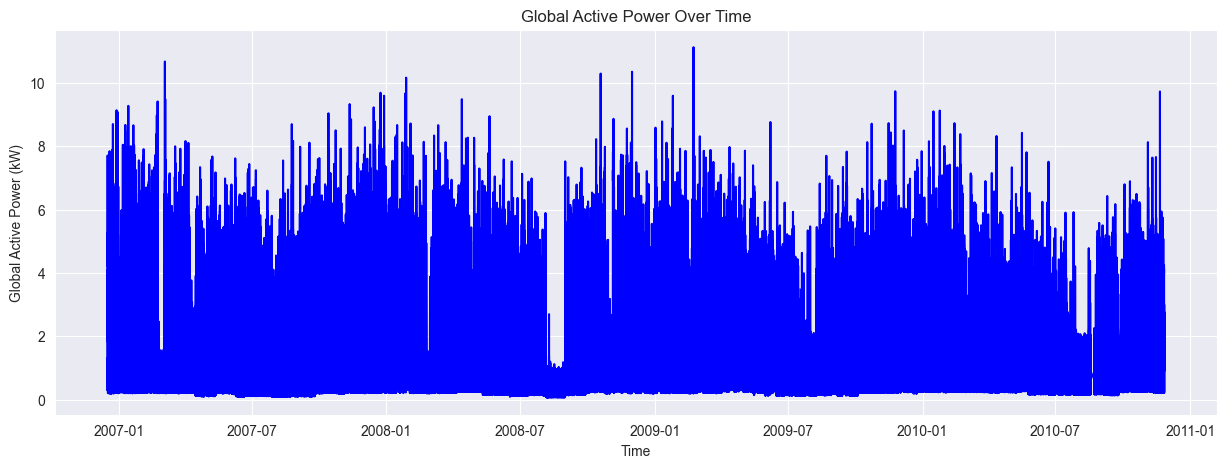

In [19]:
plt.figure(figsize=(15,5))
plt.plot(data.index, data["Global_active_power"], color="blue")
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)
plt.show()

We can see how this plot is difficult to interpet, this is because data is per-minute. This may is too granular and noisy for our models, we will try to aggregate it.

In [20]:
hourly_data = data[num_cols].resample('H').agg({
    "Global_active_power": "mean",   
    "Global_reactive_power": "mean",   
    "Voltage": "mean",                  
    "Global_intensity": "mean",        
    "Sub_metering_1": "sum",         
    "Sub_metering_2": "sum",      
    "Sub_metering_3": "sum"       
})

C:\Users\fajer\AppData\Local\Temp\ipykernel_28000\2435061943.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = data[num_cols].resample('H').agg({


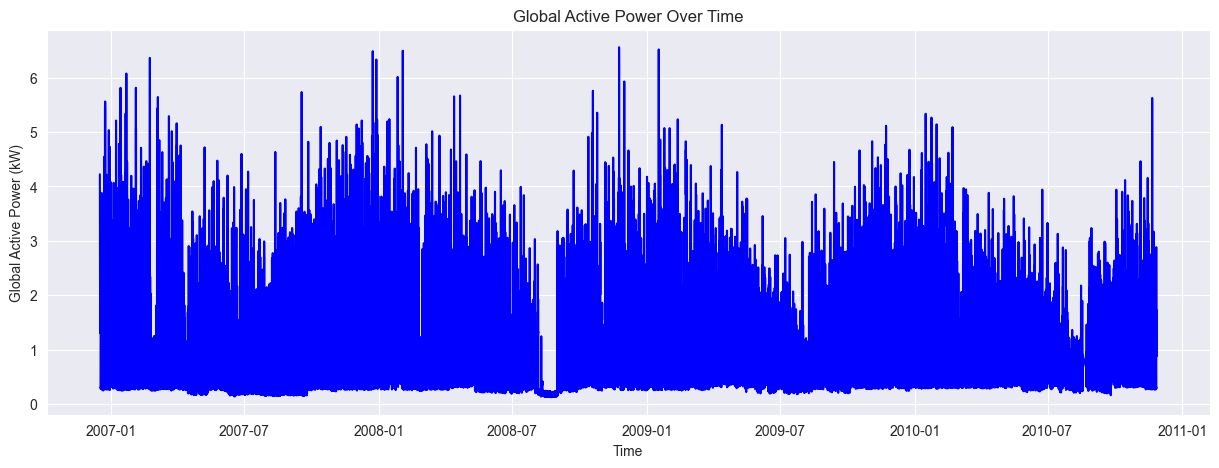

In [21]:
plt.figure(figsize=(15,5))
plt.plot(hourly_data.index, hourly_data["Global_active_power"], color="blue")
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)
plt.show()

We can see that the plot keeps not being interpretable at all. We are going to zoom in the plot to a better interpretation of the plot. 

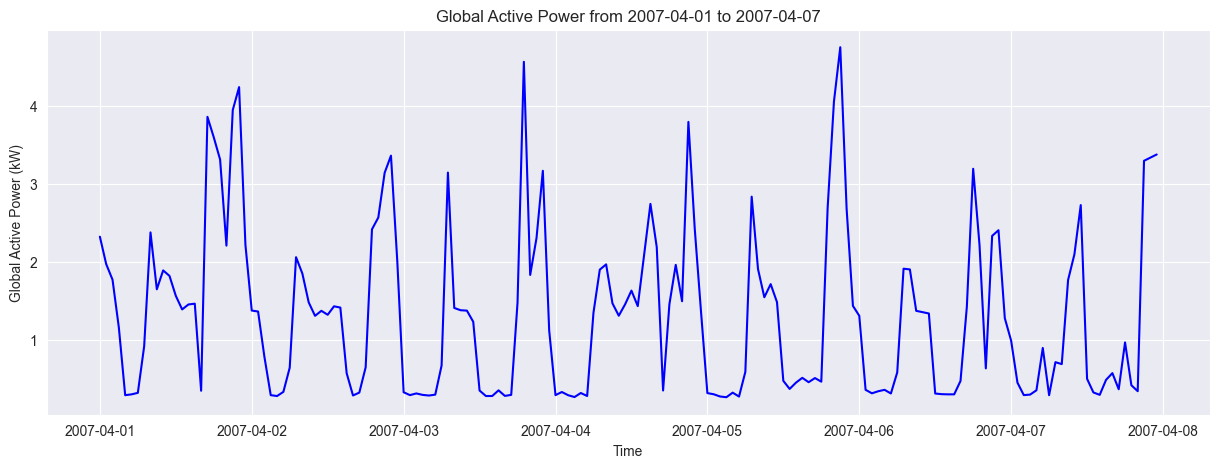

In [22]:
# Define start and end dates for zoom
start_date = "2007-04-01"
end_date   = "2007-04-07"

# Slice the data
zoom_data = hourly_data.loc[start_date:end_date]

# Plot
plt.figure(figsize=(15,5))
plt.plot(zoom_data.index, zoom_data["Global_active_power"], color="blue")
plt.title(f"Global Active Power from {start_date} to {end_date}")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)
plt.show()


We can see how this plot is more interpretable. We can see the patterns of our data and the peaks of energy consumption over the day and days. We are going to regress and predict data by hour, as we have a lot of data, in order to capture day cycles or weekday vs weekend patterns for example.

## Analyzing features

Before doing feature selection we are going to analyze each feature, in order to search for abnormal values or outliers.

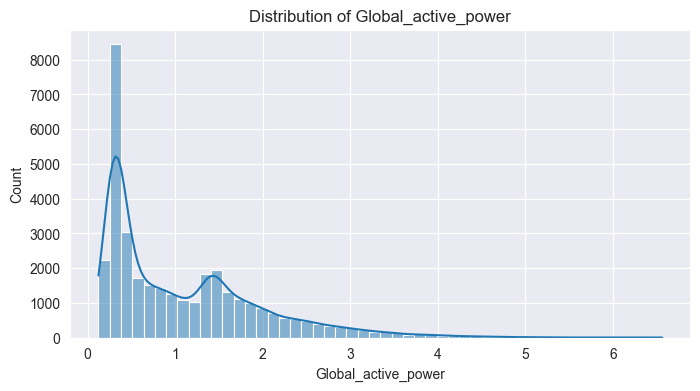

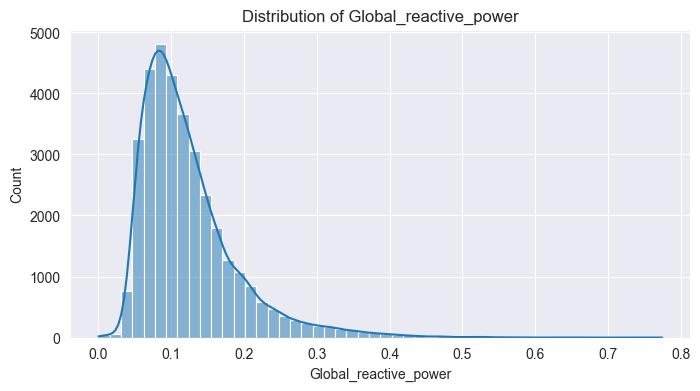

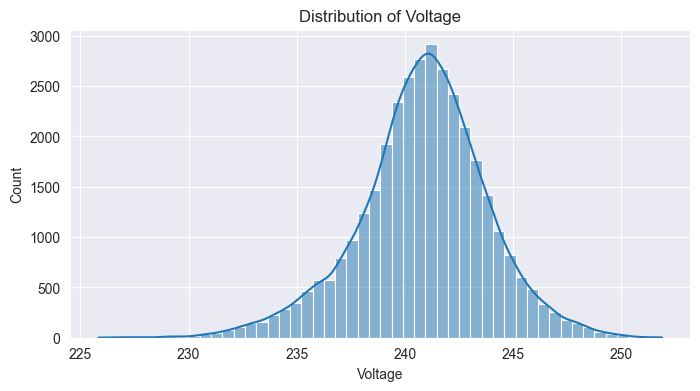

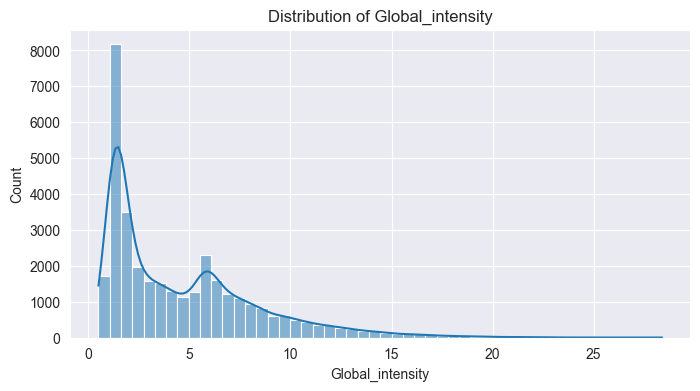

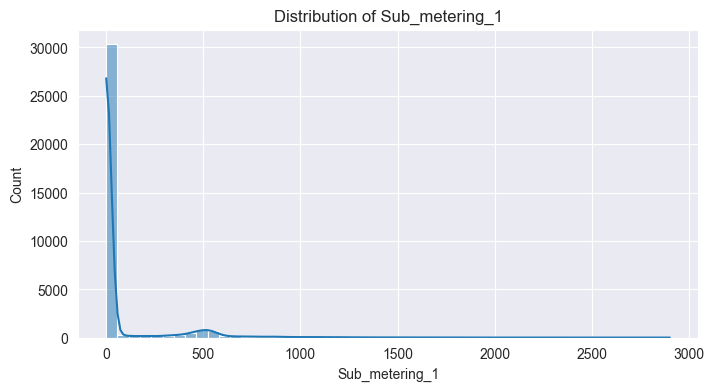

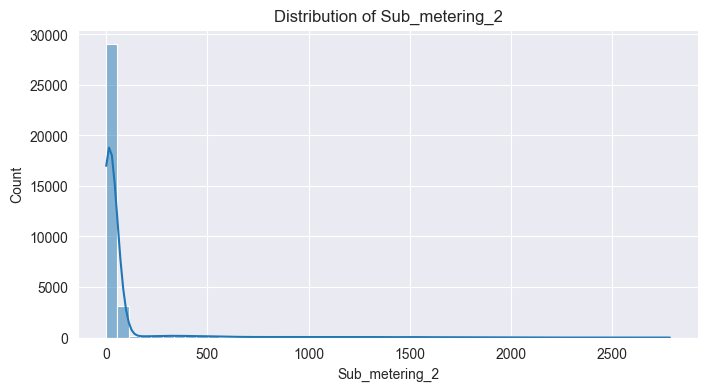

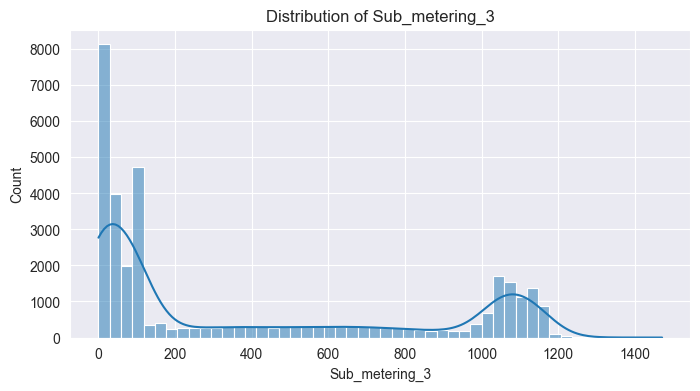

In [23]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(hourly_data[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Here we can see the distributions of the variables. We can see how, excluding voltage, we have very large tails on the right on almost all distributions. This is because, as it is hourly data 0 is the most present value in all categories. We want to treat this cues and its extreme values firstly for those columns which are not sub_metering. To impute them, we are going to use temporal interpolation using 99,5% percentile, in order to be conservative as all is real data.

In [24]:
cols_to_impute = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]

outlier_flags = pd.DataFrame(index=hourly_data.index)

for col in cols_to_impute:
    lower = hourly_data[col].quantile(0.005)
    upper = hourly_data[col].quantile(0.995)
    outlier_flags[col] = ((hourly_data[col] < lower) | (hourly_data[col] > upper))
    print(f"{col}: {outlier_flags[col].sum()} outliers detected")

hourly_data_imputed = hourly_data.copy()
for col in cols_to_impute:
    hourly_data_imputed.loc[outlier_flags[col], col] = np.nan

hourly_data_imputed[cols_to_impute] = hourly_data_imputed[cols_to_impute].interpolate(method="time")

hourly_data_imputed[cols_to_impute] = hourly_data_imputed[cols_to_impute].ffill().bfill()

print(hourly_data_imputed[cols_to_impute].isna().sum())

Global_active_power: 346 outliers detected
Global_reactive_power: 346 outliers detected
Voltage: 346 outliers detected
Global_intensity: 342 outliers detected
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
dtype: int64


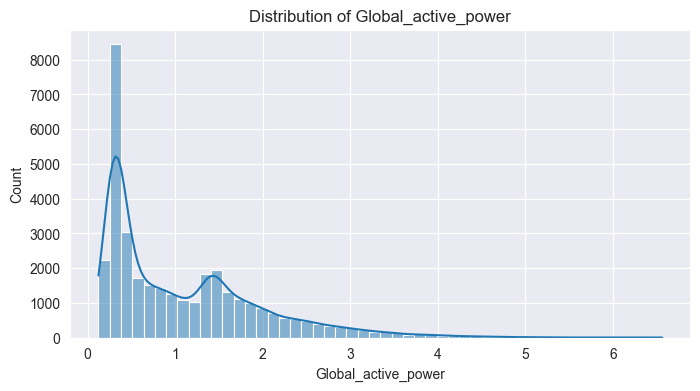

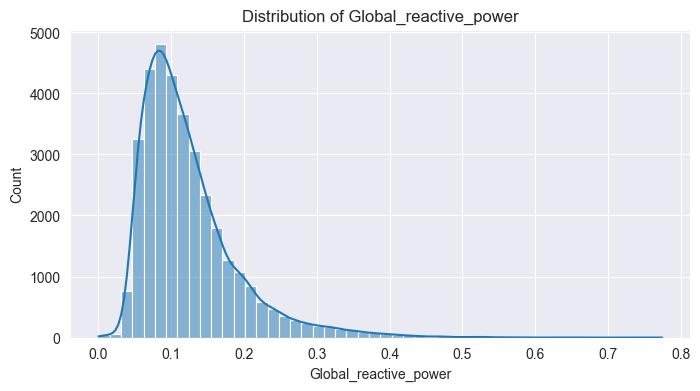

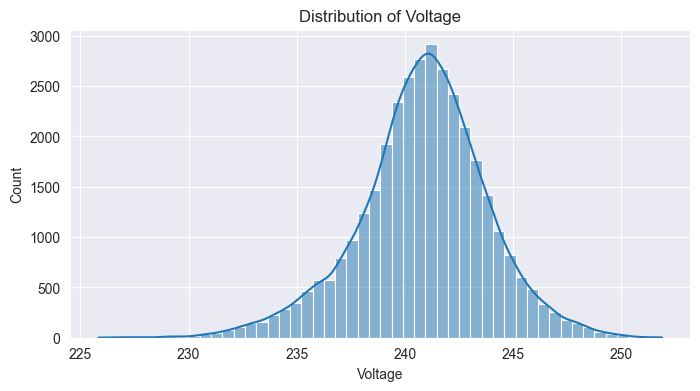

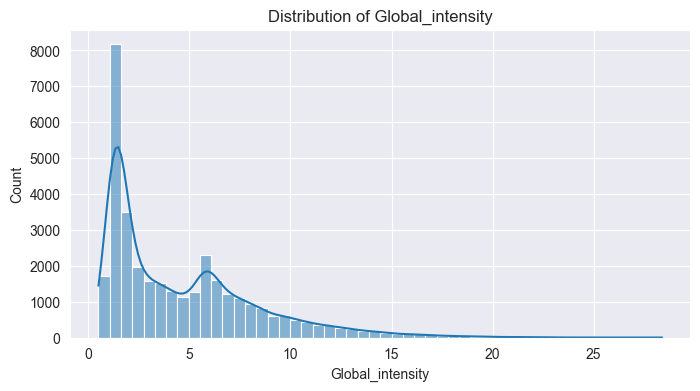

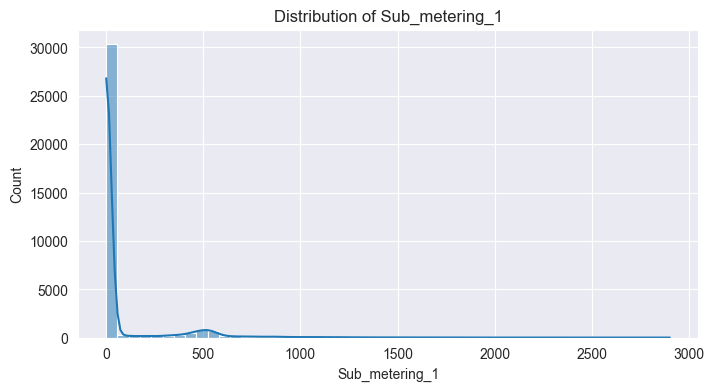

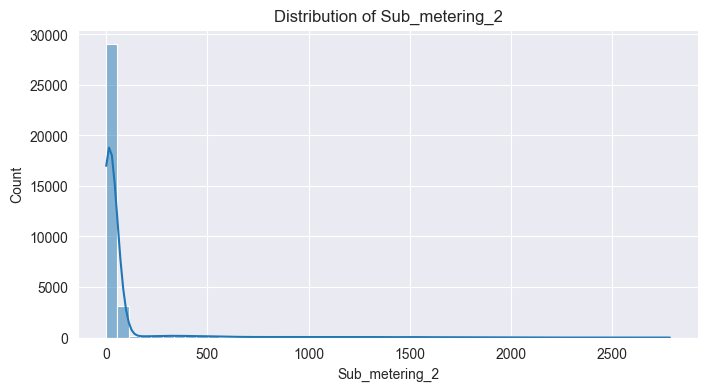

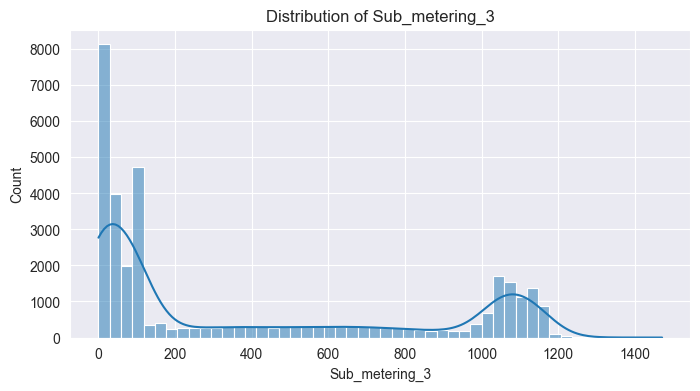

In [25]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(hourly_data[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

This are the final distributions, which has not changed a lot but represent the real data. 

Before doing feature selection, we have decided not toa apply the log to this skewed distributions because we are mostly going to use tree-based models which are very robust to skewness and dont supose normality.

## Feature Selection

Now we are going to do feature selection, in order to know which variables are the ones which explain the most the target variable.

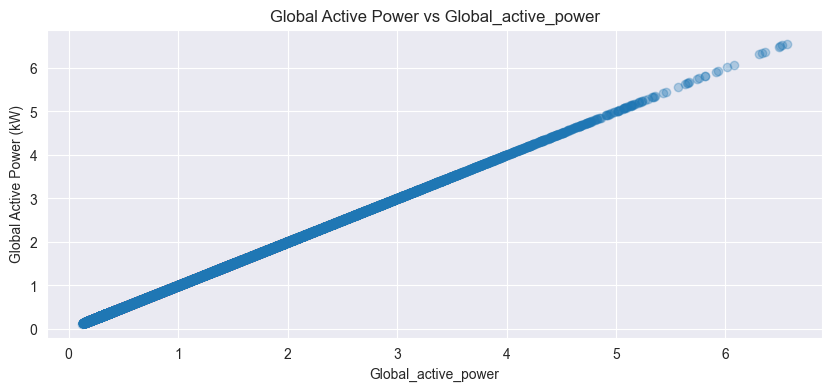

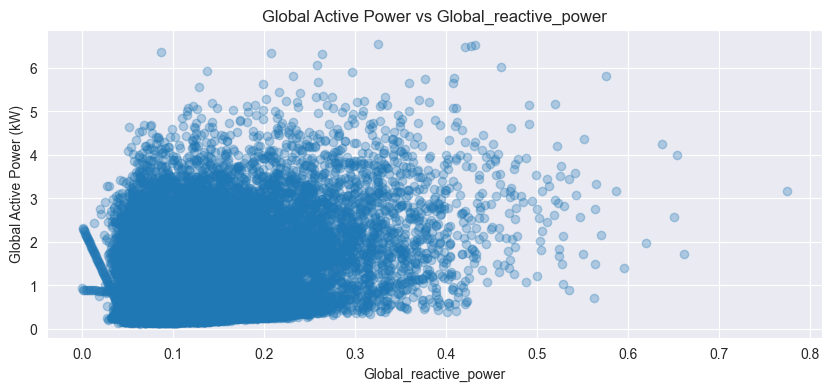

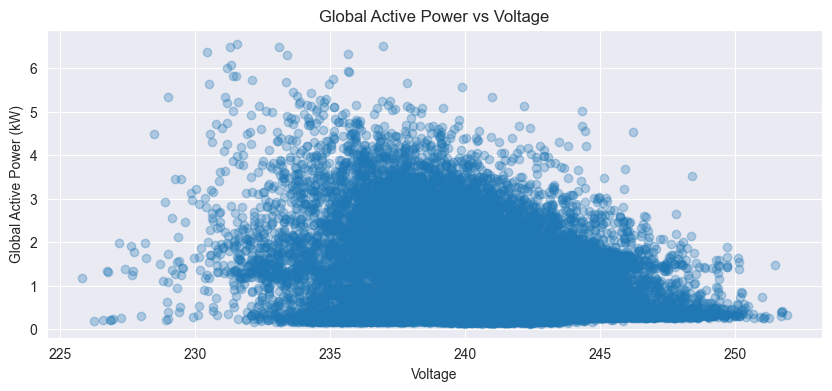

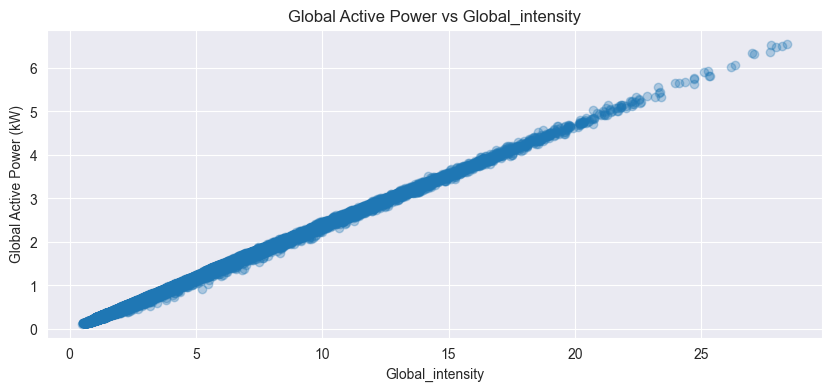

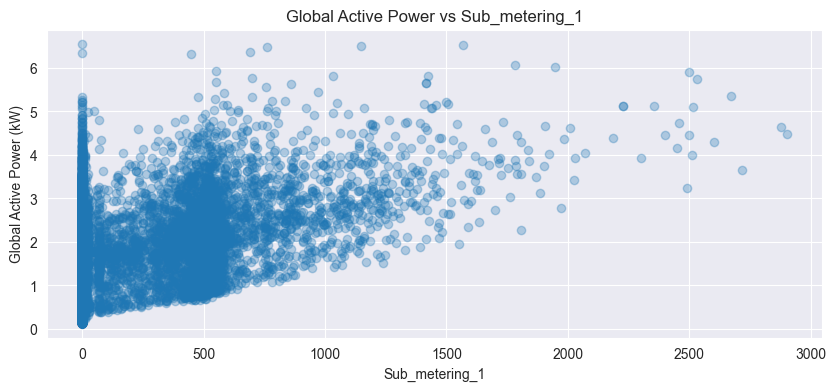

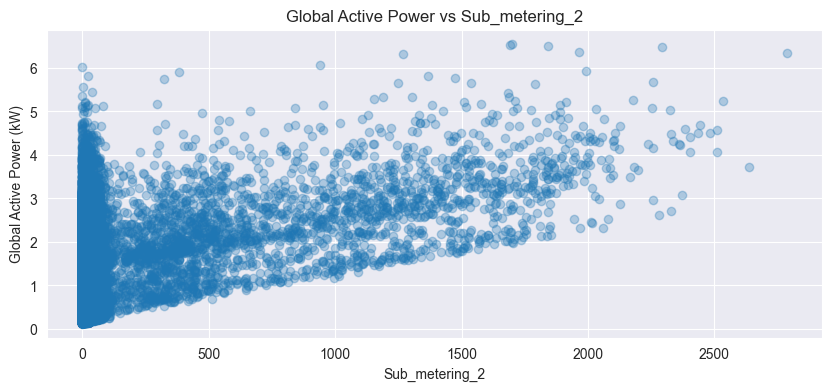

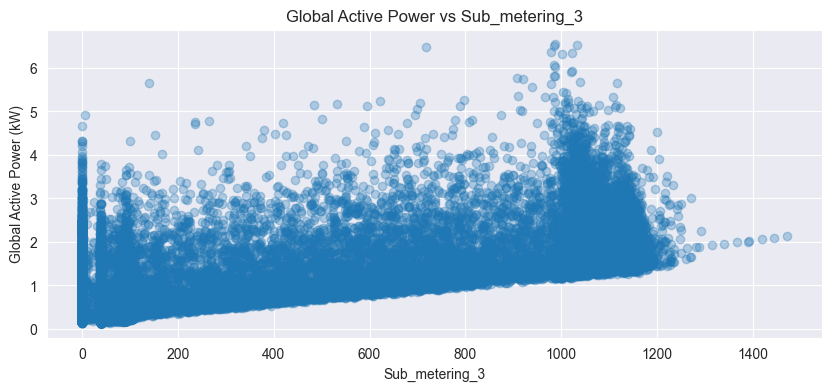

In [26]:
for col in num_cols:
    plt.figure(figsize=(10,4))
    plt.scatter(hourly_data[col], hourly_data["Global_active_power"], alpha=0.3)
    plt.title(f"Global Active Power vs {col}")
    plt.xlabel(col)
    plt.ylabel("Global Active Power (kW)")
    plt.grid(True)
    plt.show()

From the plots we can see some infromation for the variables. 
- Global_Reactive_Power: We can't see no patters as the points are distributed all allong the graph
- Voltage: This relation is a bit strange. While it seems to be normal, we can see that the left cue is very wide and with outliers.
- Global_intensity: This is the more clear one. We can see an almost perfect linear relation with them. This means that this will be grat to if we do linear regression
- Sub_metering: We can see a positive trend in all three

Next step is to look at the correlations, to see which variables are linea distributed with the target.

Correlation with Global_active_power:
Global_active_power      1.000000
Global_intensity         0.999419
Sub_metering_3           0.696029
Sub_metering_1           0.495645
Sub_metering_2           0.439239
Global_reactive_power    0.307192
Voltage                 -0.374436
Name: Global_active_power, dtype: float64


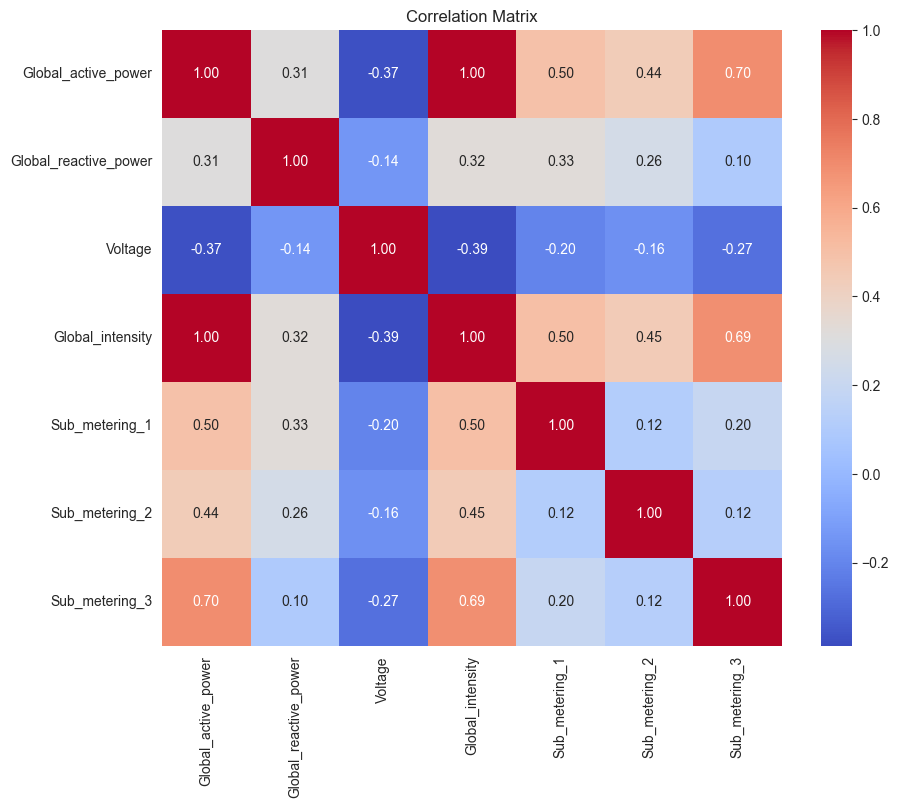

In [27]:
corr_matrix = hourly_data[num_cols].corr()

print("Correlation with Global_active_power:")
print(corr_matrix["Global_active_power"].sort_values(ascending=False))

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Intensity is the most correlated with the target. In fact it has the maximum correlation. It is followed by sub_metering_3 and it is interesting to see the negative correlation with the voltage. At this point we only see that global intensity is the one which explaine the best the target, followed by Sub_metering_3.

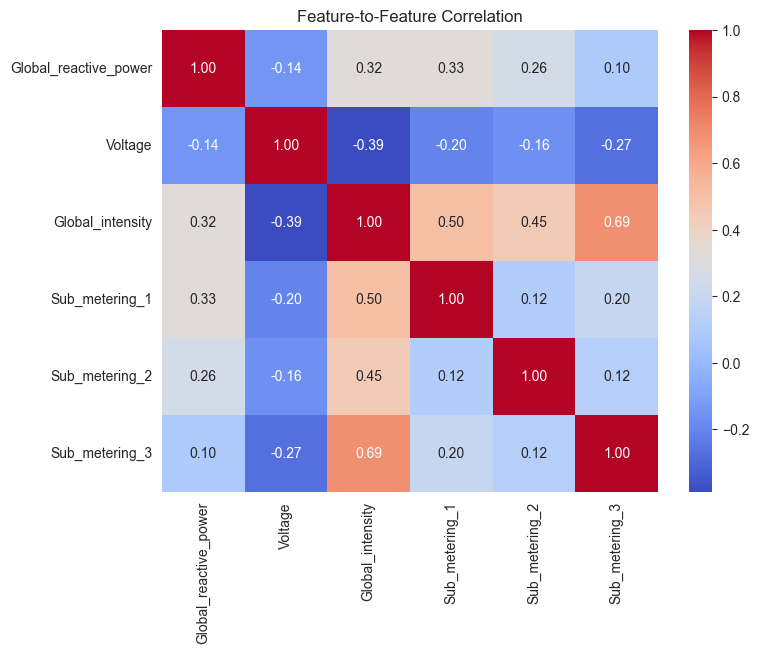

In [28]:
features_only = num_cols.copy()
features_only.remove("Global_active_power")

feature_corr = hourly_data[features_only].corr()

plt.figure(figsize=(8,6))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature-to-Feature Correlation")
plt.show()

In this step we checked mor multicolinearity but we did not found anything.

To further analyze features, we are going to use a simple model to asses feature importance.

Feature importance:
Global_intensity         0.999139
Voltage                  0.000339
Global_reactive_power    0.000277
Sub_metering_3           0.000127
Sub_metering_2           0.000060
Sub_metering_1           0.000058
dtype: float64


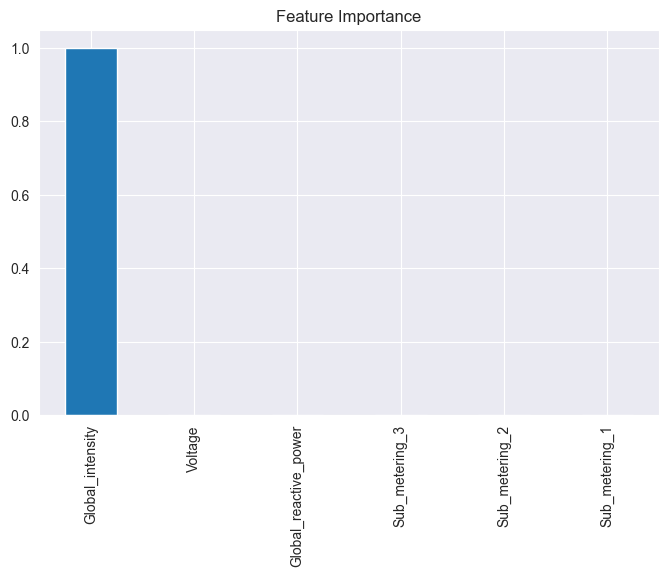

In [29]:
X = hourly_data[features_only]
y = hourly_data["Global_active_power"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature importance:")
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

As we can see, global intensity is the one which dominates in the prediction. For this reason, it is the only column which we are going to use for the regression, as the other ones only add noise to the model.

In [30]:
X = hourly_data[["Global_intensity"]]
y = hourly_data["Global_active_power"]

In [31]:
X.head()

,Global_intensity
datetime,
2006-12-16 17:00:00,18.100000
2006-12-16 18:00:00,15.600000
2006-12-16 19:00:00,14.503333
2006-12-16 20:00:00,13.916667
2006-12-16 21:00:00,13.046667


## B

The dataset we have contains about 2,075,259 observations of electricity consumption with seven numeric measurement features and timestamp information. The target variable (power consumption) and the final predictor (global intensity) are strongly skewed, and the data are time-ordered. Because of this, we chose tree-based models for the analysis. These models do not assume normal distributions, are not affected by skewed data, and can naturally handle non-linear relationships between features, that is the justification to out decision. They are also easy to interpret, which help understand how each feature affects the predictions. Cross-validation will be used to find the best model and give the best results. We think this choice provides a good balance between accurate predictions and clear and understandable results. We think this is the best approach given our data and preprocessing performed.

## 4.2 Modeling and evaluation

# A

We use the hourly aggregated and cleaned dataset obtained in section 4.1. The dataset is split into training and testing subsets in a time-consistent manner:

In [32]:
X = hourly_data[["Global_intensity"]]
y = hourly_data["Global_active_power"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


To determine the best-performing regression approach for this dataset, three model families were evaluated:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

All models were trained on the training subset and evaluated on the test subset.
The following metrics were used:
- Mean Absolute Error
- Root Mean Squared Error
- Coefficient of determination

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    }

results


{'Linear Regression': {'MAE': 0.021339025352794163,
  'RMSE': np.float64(0.02992716720803053),
  'R2': 0.9983115120350776},
 'Random Forest': {'MAE': 0.020915654777506575,
  'RMSE': np.float64(0.030191951423235715),
  'R2': 0.998281501658448},
 'Gradient Boosting': {'MAE': 0.020113601230466044,
  'RMSE': np.float64(0.028928589823939026),
  'R2': 0.998422311439328}}

The Gradient Boosting model is chosen as the final model because:
- It provides the highest predictive accuracy among the tested models.
- It captures minor nonlinear structures that linear regression cannot model.
- It avoids overfitting due to the large size and temporal structure of the dataset.
- It delivers robust performance even with a single strong predictor.

# B

The modeling approach used in this project was based on insights gathered during the exploratory data analysis. The preprocessing revealed that Global_intensity is almost perfectly correlated with Global_active_power, making it the most informative and reliable predictor for regression modeling. This justified reducing the feature set to a single variable, simplifying the model while avoiding unnecessary noise introduced by weakly informative features.
The selection of models—Linear Regression, Random Forest, and Gradient Boosting—allowed evaluation across different levels of model complexity. The results demonstrated that all models performed exceptionally well, largely due to the strongly deterministic relationship between the predictor and the target variable. Nevertheless, the Gradient Boosting Regressor provided the best overall performance, achieving the lowest prediction error and the highest R² score.

- Data preprocessing and aggregation improved signal clarity and reduced noise, leading to more stable model behavior.
- Feature reduction prevented overfitting and simplified the modeling pipeline.
- Use of non-shuffled temporal train-test split ensured that evaluation reflects real predictive performance on future observations, which is essential for time-oriented data.
- Comparison of model families showed that increasing model flexibility yields small but consistent improvements

